<a href="https://colab.research.google.com/github/eparks8/ECGR-5105-Intro-to-ML/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1: Gradient Descent

## Imports

### Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data

[[0.         3.44       0.44      ]
 [0.04040404 0.1349495  0.88848485]
 [0.08080808 0.82989899 1.3369697 ]
 [0.12121212 1.52484848 1.78545454]
 [0.16161616 2.21979798 2.23393939]]
[4.38754501 2.6796499  2.96848981 3.25406475 3.53637472]


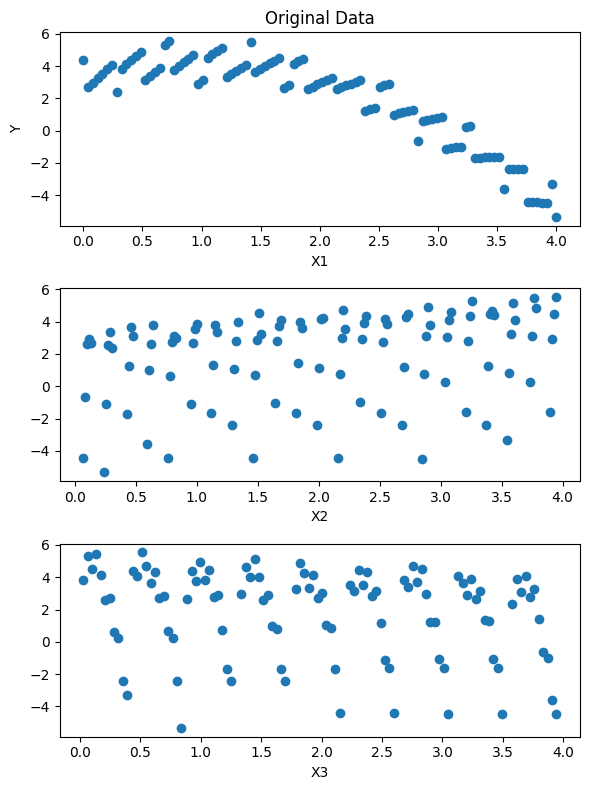

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HW1/D3.csv")

X0 = np.ones(df.shape[0])
X = df.values[:,0:3]
Y  = df.values[:,3]

print(X[0:5,:])
print(Y[0:5])

fig, axs = plt.subplots(3, 1, figsize=(6, 8))
plt.subplot(3, 1, 1)
plt.title('Original Data')
plt.xlabel('X1')
plt.ylabel('Y')
plt.subplot(3, 1, 2)
plt.xlabel('X2')
plt.subplot(3, 1, 3)
plt.xlabel('X3')
plt.subplot(3, 1, 1)
x1_plot = plt.scatter(X[:,0],Y)
plt.subplot(3, 1, 2)
x2_plot = plt.scatter(X[:,1],Y)
plt.subplot(3, 1, 3)
x3_plot = plt.scatter(X[:,2],Y)
plt.tight_layout()
plt.show()

## Helper Functions

In [ ]:
def cost(X, Y, m, thetas):
  """
  Mean Squared Error cost function.

  Args:
    X (numpy.ndarray): Input features, including X0.
    Y (numpy.ndarray): Target values.
    m (int): Number of samples.
    thetas (numpy.ndarray): Numpy array of theta values.

  Returns:
    cost (float): Mean Squared Error.
  """

  predictions = X.dot(thetas)
  errors = np.subtract(predictions,Y)
  return (1/(2*m))*np.sum(np.square(errors))

In [ ]:
def gradient_descent(X, Y, thetas, alpha, max_iters, delta):
  """
  Linear Regression with Gradient Descent.

  Args:
    X (numpy.ndarray): Input features, including X0.
    Y (numpy.ndarray): Target values.
    thetas (numpy.ndarray): Numpy array of theta values.
    alpha (float): Learning rate.
    max_iters (int): Maximum number of iterations.
    delta (float): Convergence threshold.

  Returns:
    best (dict): Dictionary containing best parameters and cost history.
  """

  thetas = np.array(thetas)
  m = Y.shape[0]
  cost_history = []

  # Loop for gradient descent iterations
  for k in range(max_iters):
    # Calculate current cost and append to history
    current_cost = cost(X, Y, m, thetas)
    cost_history.append(current_cost)

    # Check for convergence after the first iteration
    if k > 0 and abs(cost_history[k-1] - cost_history[k]) < delta:
      break

    predictions = X.dot(thetas)
    errors = np.subtract(predictions,Y)
    gradients = (1/m)*X.T.dot(errors)
    thetas = thetas - alpha*gradients

  return np.array(cost_history), thetas

## Problem 1: Isolated Explanatory Variables

Linear Model: h(x) = 4.599 + -1.521*X1
Final Cost for X1: 1.210
Linear Model: h(x) = 1.105 + 0.362*X2
Final Cost for X2: 3.626
Linear Model: h(x) = 1.564 + -0.003*X3
Final Cost for X3: 3.852


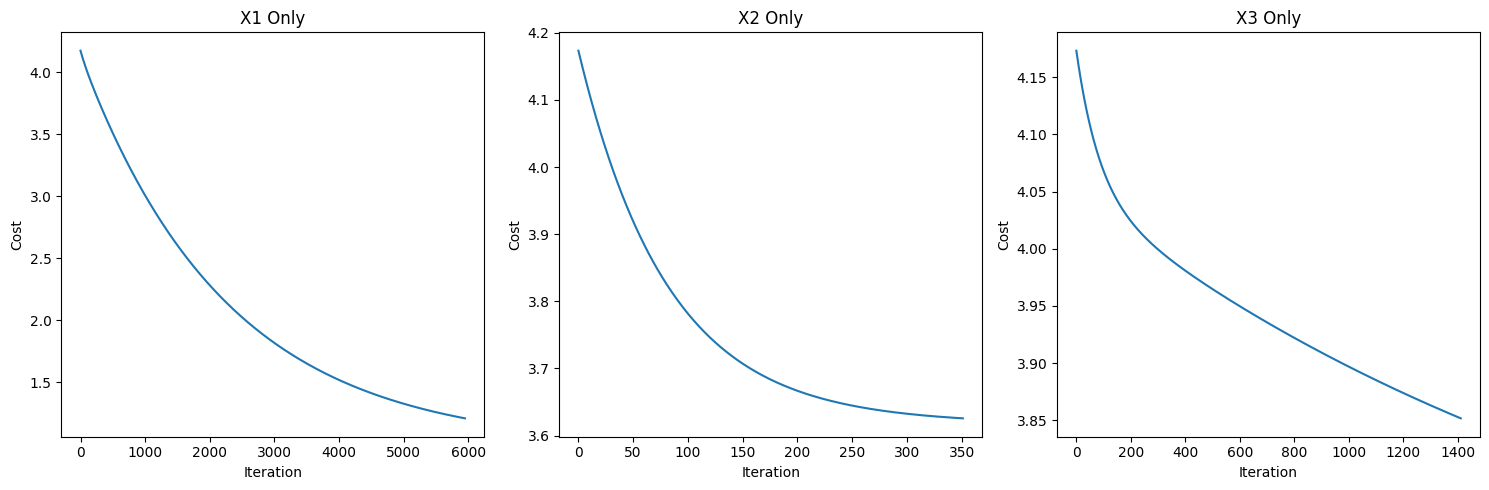

In [ ]:
x1_only_cost, x1_only_thetas = gradient_descent(np.column_stack((X0, X[:, 0])),Y,np.array([1.,0.]),0.001,10000,0.0001)
print(f"Linear Model: h(x) = {x1_only_thetas[0]:.3f} + {x1_only_thetas[1]:.3f}*X1")
print(f"Final Cost for X1: {x1_only_cost[-1]:.3f}")
x2_only_cost, x2_only_thetas = gradient_descent(np.column_stack((X0, X[:, 1])),Y,np.array([1.,0.]),0.001,10000,0.0001)
print(f"Linear Model: h(x) = {x2_only_thetas[0]:.3f} + {x2_only_thetas[1]:.3f}*X2")
print(f"Final Cost for X2: {x2_only_cost[-1]:.3f}")
x3_only_cost, x3_only_thetas = gradient_descent(np.column_stack((X0, X[:, 2])),Y,np.array([1.,0.]),0.001,10000,0.0001)
print(f"Linear Model: h(x) = {x3_only_thetas[0]:.3f} + {x3_only_thetas[1]:.3f}*X3")
print(f"Final Cost for X3: {x3_only_cost[-1]:.3f}")

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(x1_only_cost)
plt.title("X1 Only")
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.subplot(1, 3, 2)
plt.plot(x2_only_cost)
plt.title("X2 Only")
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.subplot(1, 3, 3)
plt.plot(x3_only_cost)
plt.title("X3 Only")
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.tight_layout()
plt.show()

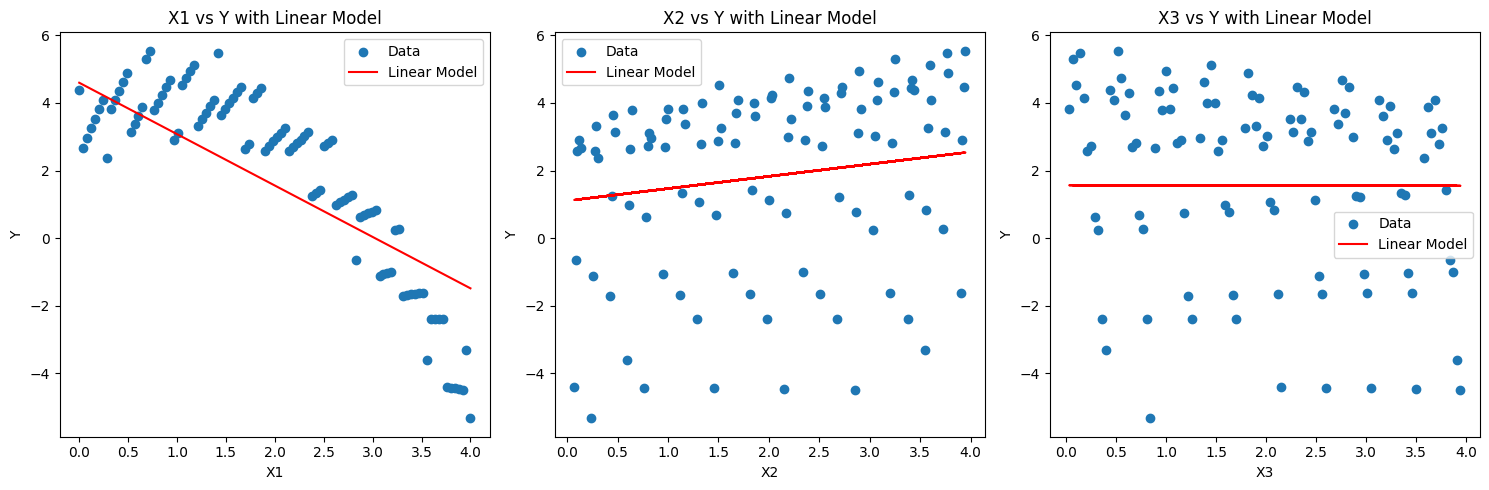

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot for X1
plt.subplot(1, 3, 1)
plt.scatter(X[:,0],Y, label='Data')
plt.plot(X[:,0], x1_only_thetas[0] + x1_only_thetas[1]*X[:,0], color='red', label='Linear Model')
plt.title('X1 vs Y with Linear Model')
plt.xlabel('X1')
plt.ylabel('Y')
plt.legend()

# Plot for X2
plt.subplot(1, 3, 2)
plt.scatter(X[:,1],Y, label='Data')
plt.plot(X[:,1], x2_only_thetas[0] + x2_only_thetas[1]*X[:,1], color='red', label='Linear Model')
plt.title('X2 vs Y with Linear Model')
plt.xlabel('X2')
plt.ylabel('Y')
plt.legend()

# Plot for X3
plt.subplot(1, 3, 3)
plt.scatter(X[:,2],Y, label='Data')
plt.plot(X[:,2], x3_only_thetas[0] + x3_only_thetas[1]*X[:,2], color='red', label='Linear Model')
plt.title('X3 vs Y with Linear Model')
plt.xlabel('X3')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

## Problem 2: Combined Explanatory Variables

Best parameters when training with all variables:
Theta 1: -1.551, Theta 2: 1.027, Theta 3: 0.169, Alpha: 0.001, Delta: 0.0001
Linear Model: h(x) = 2.263 + -1.551*X1 + 1.027*X2 + 0.169*X3
Final Cost: 1.235


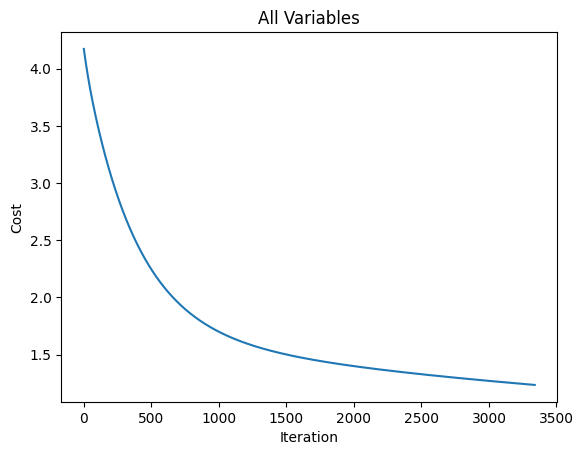

In [ ]:
all_cost, all_thetas = gradient_descent(np.column_stack((X0,X)),Y,np.array([1.,0.,0.,0.]),0.001,10000,0.0001)
print("Best parameters when training with all variables:")
print(f"Theta 1: {all_thetas[1]:.3f}, Theta 2: {all_thetas[2]:.3f}, Theta 3: {all_thetas[3]:.3f}, Alpha: {0.001:.3f}, Delta: {0.0001:.4f}")
print(f"Linear Model: h(x) = {all_thetas[0]:.3f} + {all_thetas[1]:.3f}*X1 + {all_thetas[2]:.3f}*X2 + {all_thetas[3]:.3f}*X3")
print(f"Final Cost: {all_cost[-1]:.3f}")
plt.plot(all_cost)
plt.title('All Variables')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.show()

In [ ]:
input_X_values_combined = np.array([
    [1, 1, 1],
    [2, 0, 4],
    [3, 2, 1]
])

# Add the intercept term (X0 = 1) to the input values
X0_combined = np.ones(input_X_values_combined.shape[0])
combined_X_for_prediction = np.column_stack((X0_combined, input_X_values_combined))

print("Predictions using combined linear model:")
for i, x_vals_with_intercept in enumerate(combined_X_for_prediction):
    # The actual X values are from index 1 onwards
    original_x_vals = input_X_values_combined[i]

    # Calculate prediction using all_thetas
    predicted_y_combined = np.dot(x_vals_with_intercept, all_thetas)

    print(f"\nFor X = ({original_x_vals[0]},{original_x_vals[1]},{original_x_vals[2]}):")
    print(f"  Predicted Y (using combined model): {predicted_y_combined:.3f}")

Predictions using combined linear model:

For X = (1,1,1):
  Predicted Y (using combined model): 1.908

For X = (2,0,4):
  Predicted Y (using combined model): -0.161

For X = (3,2,1):
  Predicted Y (using combined model): -0.166
